In [191]:
# data analysis
import pandas as pd
import numpy as np

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from pyampute.exploration.md_patterns import mdPatterns
from pyampute.exploration.mcar_statistical_tests import MCARTest
import missingno as msno


# preprocessing
import sklearn.utils.validation
import sys
from scipy import stats
from scipy.stats import shapiro, distributions, loguniform
from scipy.stats.mstats import winsorize
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import train_test_split, GridSearchCV, HalvingRandomSearchCV, HalvingGridSearchCV, TunedThresholdClassifierCV, FixedThresholdClassifier
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, PowerTransformer, QuantileTransformer, MinMaxScaler, KBinsDiscretizer, Binarizer, PolynomialFeatures, LabelEncoder, OneHotEncoder, OrdinalEncoder
from sklearn.compose import ColumnTransformer, make_column_selector
from feature_engine.outliers import Winsorizer
# from imblearn.over_sampling import SMOTE, SMOTENC
from sklearn.pipeline import Pipeline
from sklearn import set_config

# Feature Selection
from sklearn.feature_selection import SelectFromModel
from sklearn.feature_selection import SelectKBest, f_classif, chi2

# Modeling
from sklearn.linear_model import RidgeClassifier, LogisticRegression, RidgeClassifierCV, LogisticRegressionCV, SGDClassifier, Perceptron, PassiveAggressiveClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.dummy import DummyClassifier
import joblib
from sklearn import tree 
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier, RandomForestClassifier, ExtraTreesClassifier, BaggingClassifier, VotingClassifier, StackingClassifier
from lightgbm import LGBMClassifier 
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid, RadiusNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF


# Metrics
from sklearn.metrics import confusion_matrix, recall_score, precision_score, balanced_accuracy_score, ConfusionMatrixDisplay, classification_report, precision_recall_curve, PrecisionRecallDisplay, log_loss, brier_score_loss, roc_curve, roc_auc_score, RocCurveDisplay, det_curve, DetCurveDisplay, fbeta_score, average_precision_score, matthews_corrcoef

# Calibration
from sklearn.calibration import calibration_curve, CalibrationDisplay, CalibratedClassifierCV

# Inspection
from sklearn.inspection import PartialDependenceDisplay

# Custom Functions
from credit_risk_modeling import model_eval
import importlib
importlib.reload(model_eval)

# Class Imbalance
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.pipeline import Pipeline as imbPipeLine

## Imports

In [3]:
X_train= pd.read_csv(
    filepath_or_buffer= "../data/processed/X_train_probability.csv"
)
X_train.info()
X_train.head(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22686 entries, 0 to 22685
Data columns (total 32 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   numeric__person_age_1.0                      22686 non-null  float64
 1   numeric__person_age_2.0                      22686 non-null  float64
 2   numeric__person_income_1.0                   22686 non-null  float64
 3   numeric__person_income_2.0                   22686 non-null  float64
 4   numeric__person_emp_length_1.0               22686 non-null  float64
 5   numeric__person_emp_length_2.0               22686 non-null  float64
 6   numeric__loan_amnt_1.0                       22686 non-null  float64
 7   numeric__loan_amnt_2.0                       22686 non-null  float64
 8   numeric__loan_int_rate_1.0                   22686 non-null  float64
 9   numeric__loan_int_rate_2.0                   22686 non-null  float64
 10

,numeric__person_age_1.0,numeric__person_age_2.0,numeric__person_income_1.0,numeric__person_income_2.0,numeric__person_emp_length_1.0,numeric__person_emp_length_2.0,numeric__loan_amnt_1.0,numeric__loan_amnt_2.0,numeric__loan_int_rate_1.0,numeric__loan_int_rate_2.0,...,categorical__loan_intent_PERSONAL,categorical__loan_intent_VENTURE,categorical__loan_grade_A,categorical__loan_grade_B,categorical__loan_grade_C,categorical__loan_grade_D,categorical__loan_grade_E,categorical__loan_grade_F,categorical__loan_grade_G,categorical__cb_person_default_on_file_True
0,-0.728894,1.261899,-0.698358,1.394801,-0.669061,-0.747494,-0.729957,1.411273,1.396722,-0.707107,...,-0.452031,-0.461055,-0.701014,1.460921,-0.500744,-0.354762,-0.174851,-0.086634,-0.045564,-0.465617


In [4]:
X_test= pd.read_csv(
    filepath_or_buffer= "../data/processed/X_test_probability.csv"
)
X_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9723 entries, 0 to 9722
Data columns (total 32 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   numeric__person_age_1.0                      9723 non-null   float64
 1   numeric__person_age_2.0                      9723 non-null   float64
 2   numeric__person_income_1.0                   9723 non-null   float64
 3   numeric__person_income_2.0                   9723 non-null   float64
 4   numeric__person_emp_length_1.0               9723 non-null   float64
 5   numeric__person_emp_length_2.0               9723 non-null   float64
 6   numeric__loan_amnt_1.0                       9723 non-null   float64
 7   numeric__loan_amnt_2.0                       9723 non-null   float64
 8   numeric__loan_int_rate_1.0                   9723 non-null   float64
 9   numeric__loan_int_rate_2.0                   9723 non-null   float64
 10  

In [5]:
y_train= pd.read_csv(
    filepath_or_buffer= "../data/interim/y_train.csv"
)
y_train = y_train.values.ravel()

In [6]:
y_test= pd.read_csv(
    filepath_or_buffer= "../data/interim/y_test.csv"
)
y_test = y_test.values.ravel()

## Comparing Models

In [16]:
untuned_models = [
    BernoulliNB(),
    LogisticRegression(
        C=np.inf,
        random_state=42
    ),
    SGDClassifier(
        loss= 'log_loss',
        penalty=None,
        random_state=42,
        n_jobs=-1
    ),
    LinearDiscriminantAnalysis(), #  handles internal feature selection with n_components
    # GaussianProcessClassifier(
    #     kernel=kernel,
    #     random_state=42,
    #     n_jobs=-1
    # )
]

In [17]:
untuned_model_performance, untuned_fitted_models = model_eval.comparing_models(
    untuned_models,
    X_train,
    y_train,
    X_test,
    y_test
)

c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\linear_model\_logistic.py:1170: UserWarning: Setting penalty=None will ignore the C and l1_ratio parameters
  warnings.warn(


In [19]:
untuned_model_performance

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef
1,"LogisticRegression (penalty=deprecated, solver...",0.854396,0.673815,0.365527,0.113222,0.480977
3,LinearDiscriminantAnalysis (solver=svd),0.851276,0.661966,0.376388,0.116366,0.477959
2,"SGDClassifier (penalty=None, n_jobs=-1, l1_rat...",0.838913,0.653276,0.382267,0.117396,0.476628
0,BernoulliNB,0.828282,0.618647,0.451205,0.137161,0.435658


In [190]:
untuned_model_performance['is_untuned'] = 1

In [215]:
untuned_fitted_models

{'BernoulliNB': BernoulliNB(),
 'LogisticRegression (penalty=deprecated, solver=lbfgs, n_jobs=None, l1_ratio=0.0, class_weight=None)': LogisticRegression(C=inf, random_state=42),
 'SGDClassifier (penalty=None, n_jobs=-1, l1_ratio=0.15, class_weight=None)': SGDClassifier(loss='log_loss', n_jobs=-1, penalty=None, random_state=42),
 'LinearDiscriminantAnalysis (solver=svd)': LinearDiscriminantAnalysis()}

## Hyperparameter Tuning, Class Imbalance, Feature Selection

### Logistic Regression (L1, L2, ElasticNet)

Hyperparameter tuning the Cs regularization strength for three differet regularization methods. Class Imbalance is handled internally. Feature Selection is handled internally via regularization.

In [66]:
tuned_models=[
        LogisticRegressionCV(Cs= np.logspace(-3, 3, 10), solver='saga', max_iter=5000, class_weight='balanced', n_jobs=-1, l1_ratios=(1,), use_legacy_attributes=False),
        LogisticRegressionCV(Cs= np.logspace(-3, 3, 10), solver='saga', max_iter=5000, class_weight='balanced', n_jobs=-1, l1_ratios=(0,), use_legacy_attributes=False),
        LogisticRegressionCV(Cs= np.logspace(-3, 3, 10), solver='saga', max_iter=5000, class_weight='balanced', n_jobs=-1, l1_ratios=[0.5], use_legacy_attributes=False),
]

In [67]:
internal_tuned_model_performance, fitted_models_internal = model_eval.comparing_models(
    tuned_models,
    X_train,
    y_train,
    X_test,
    y_test
)

c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [192]:
internal_tuned_model_performance['is_untuned'] = 0

### Linear Discriminant Analysis

In [ ]:
lda_pipe = imbPipeLine(
    steps=[
        ("select", SelectKBest(score_func=f_classif)),
        ("ros", SMOTE(k_neighbors=1)),
        ("lda", LinearDiscriminantAnalysis())
    ]
)

In [164]:
lda_param_dist = {
    "select__k": stats.randint(5, 300),
    "lda__solver": ["svd, lsqr", "eigen"],
    "lda__shrinkage": ["auto", stats.uniform(0, 1)]
}

In [ ]:
lda_tuned = HalvingRandomSearchCV(
    estimator= lda_pipe,
    param_distributions=lda_param_dist,
    scoring = 'roc_auc',
    n_jobs=-1
)

### SGDClassifier (L1)

In [166]:
sgd_classifier = SGDClassifier(
    loss= 'log_loss',
    max_iter= 10000,
    penalty= 'l1',
    class_weight= 'balanced',
    n_jobs=-1
)

In [167]:
sgd_param_grid = {
    'alpha': loguniform(1e-2, 1e6),
}

In [168]:
sgd_tuned = HalvingRandomSearchCV(
    estimator= sgd_classifier,
    param_distributions=sgd_param_grid,
    scoring = 'roc_auc',
    n_jobs=-1
)

### BernoulliNB

In [177]:
nb_pipe = imbPipeLine(
    steps=[
        ('select', SelectKBest(score_func=f_classif)),
        ('sampling', SMOTE(k_neighbors=1)),
        ('nb', BernoulliNB())
    ]
)

In [178]:
nb_param_grid = {
    'nb__alpha': stats.loguniform(1e-4, 1e1)
}

In [179]:
nb_tuned = HalvingRandomSearchCV(
    estimator= nb_pipe,
    param_distributions=nb_param_grid,
    scoring = 'roc_auc',
    n_jobs=-1
)

In [180]:
manually_tuned_models = [
    lda_tuned,
    nb_tuned,
    sgd_tuned
]

In [181]:
manually_tuned_model_performance, fitted_models_manual= model_eval.comparing_manually_tuned_models(
    manually_tuned_models,
    X_train,
    y_train,
    X_test,
    y_test
)

c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
4280 fits failed out of a total of 5670.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\billy\anaconda3\envs\

In [187]:
manually_tuned_model_performance['is_untuned'] = 0

In [193]:
tuned_model_performances = model_eval.combine_model_performance(
    internal_tuned_model_performance,
    manually_tuned_model_performance,
    untuned_model_performance
)

In [194]:
tuned_model_performances

,model,roc_auc,pr_auc,log_loss,brier_score,matthews_corrcoef,is_untuned
1,"LogisticRegression (penalty=deprecated, solver...",0.854396,0.673815,0.365527,0.113222,0.480977,1
0,Pipeline,0.854187,0.660221,0.464911,0.150656,0.489979,0
1,"LogisticRegressionCV (penalty=deprecated, solv...",0.854007,0.665248,0.478007,0.154866,0.493519,0
2,"SGDClassifier (penalty=l1, n_jobs=-1, l1_ratio...",0.853111,0.640521,0.505884,0.155538,0.490010,0
3,LinearDiscriminantAnalysis (solver=svd),0.851276,0.661966,0.376388,0.116366,0.477959,1
2,"LogisticRegressionCV (penalty=deprecated, solv...",0.848250,0.640642,0.500850,0.162320,0.495267,0
2,"SGDClassifier (penalty=None, n_jobs=-1, l1_rat...",0.838913,0.653276,0.382267,0.117396,0.476628,1
0,"LogisticRegressionCV (penalty=deprecated, solv...",0.829734,0.588459,0.530831,0.174004,0.488974,0
0,BernoulliNB,0.828282,0.618647,0.451205,0.137161,0.435658,1
1,Pipeline,0.809206,0.561070,0.605184,0.191957,0.428040,0


### Evaluate Calibration

### Evaluate Calibration

Log loss (sigmoid): 0.3655
Brier score (sigmoid): 0.1132
Log loss (isotonic): 0.3634
Brier score (isotonic): 0.1129


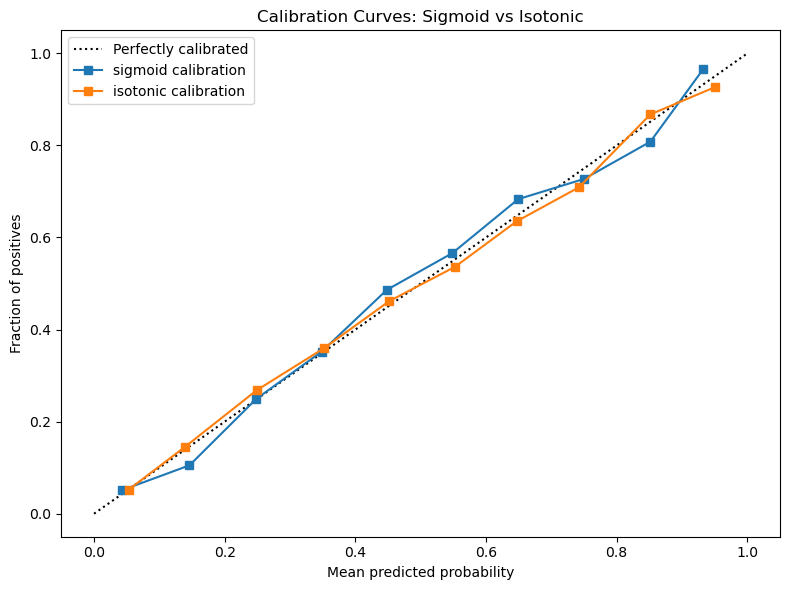

In [200]:
top_performing_calibrated_models = model_eval.evaluate_calibration(
    tuned_model_performances,
    untuned_fitted_models,
    X_train,
    y_train,
    X_test, 
    y_test
)

In [201]:
top_performing_calibrated_models

{'sigmoid': CalibratedClassifierCV(estimator=LogisticRegression(C=inf, random_state=42),
                        n_jobs=-1),
 'isotonic': CalibratedClassifierCV(estimator=LogisticRegression(C=inf, random_state=42),
                        method='isotonic', n_jobs=-1)}

In [203]:
top_performing_calibrated_model = top_performing_calibrated_models['isotonic']

Classification Report (Base Estimator):
               precision    recall  f1-score   support

       False       0.87      0.94      0.90      7597
        True       0.70      0.48      0.57      2126

    accuracy                           0.84      9723
   macro avg       0.78      0.71      0.74      9723
weighted avg       0.83      0.84      0.83      9723

Business Cost (Base Estimator): $11323500


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifi

Classification Report (Tuned Estimator):
               precision    recall  f1-score   support

       False       0.00      0.00      0.00      7597
        True       0.22      1.00      0.36      2126

    accuracy                           0.22      9723
   macro avg       0.11      0.50      0.18      9723
weighted avg       0.05      0.22      0.08      9723

Business Cost (Tuned Estimator): $3798500


c:\Users\billy\anaconda3\envs\credit_risk_modeling\Lib\site-packages\sklearn\utils\_plotting.py:440: FutureWarning: y_pred was deprecated in 1.8 and will be removed in 1.10. Please use `y_score` instead.
  warnings.warn(


Classification Report (Chosen Threshold):
               precision    recall  f1-score   support

       False       0.97      0.31      0.47      7597
        True       0.28      0.96      0.43      2126

    accuracy                           0.45      9723
   macro avg       0.62      0.63      0.45      9723
weighted avg       0.82      0.45      0.46      9723

Business Cost (Chosen Threshold): $3416000


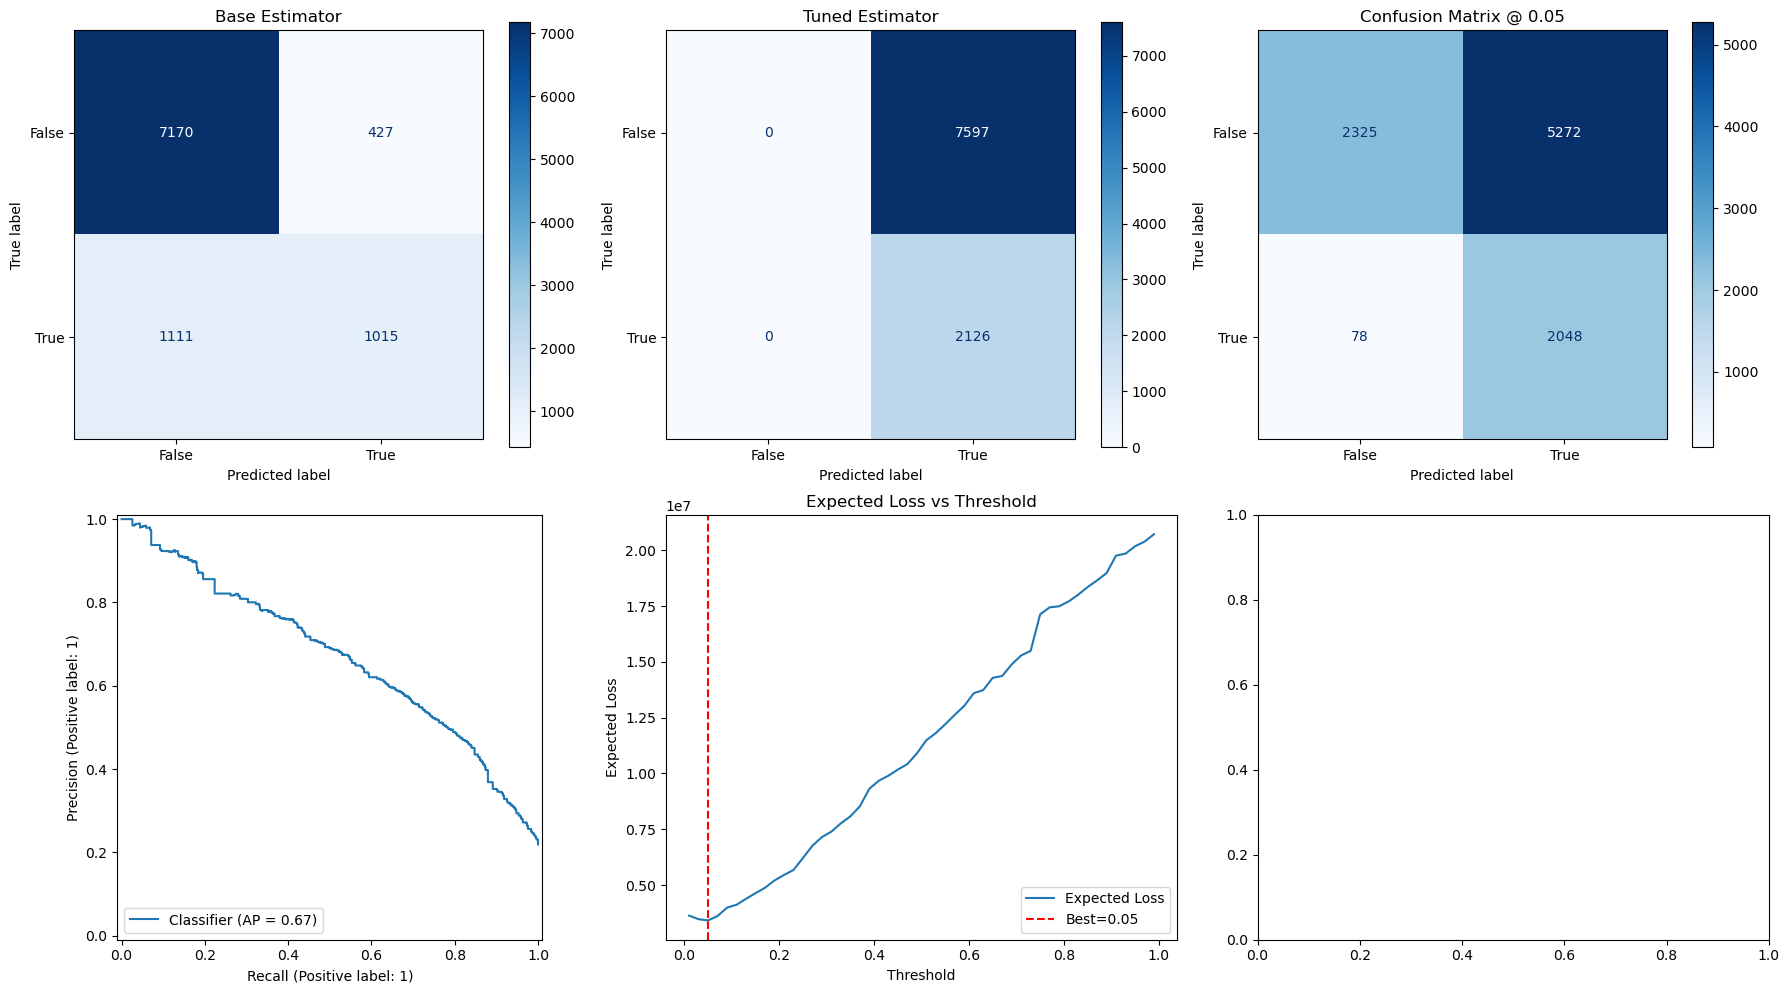

In [204]:
decision_models = model_eval.decision_threshold_comparisons(
    top_performing_calibrated_model,
    X_train,
    y_train,
    X_test, 
    y_test
)

In [206]:
decision_models

{'base_estimator': CalibratedClassifierCV(estimator=LogisticRegression(C=inf, random_state=42),
                        method='isotonic', n_jobs=-1),
 'tuned_estimator': TunedThresholdClassifierCV(cv=5,
                            estimator=CalibratedClassifierCV(estimator=LogisticRegression(C=inf,
                                                                                          random_state=42),
                                                             method='isotonic',
                                                             n_jobs=-1),
                            n_jobs=-1, random_state=42, scoring='recall'),
 'chosen_estimator': FixedThresholdClassifier(estimator=CalibratedClassifierCV(estimator=LogisticRegression(C=inf,
                                                                                        random_state=42),
                                                           method='isotonic',
                                                           n_job

In [209]:
top_performing_model = decision_models['chosen_estimator']

In [210]:
joblib.dump(
    top_performing_model,
    "../models/best_probability_model.pkl"
)

['../models/best_probability_model.pkl']